In [15]:
import cv2
import numpy as np
image = cv2.imread('pic1.png')
resized = cv2.resize(image, (224,224))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

mean_intensity = float(np.mean(gray))

deci_threshold = 127
if mean_intensity>=deci_threshold:
    pred_class = "Class B"
else:
    pred_class = "Class A"
print("mean_intensity:", round(mean_intensity,2))
print("Class belong:", pred_class)

out_put = resized.copy()
cv2.putText(out_put,pred_class,(20,40),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

cv2.imshow("Binary_classification", out_put)
cv2.waitKey(0)
cv2.destroyAllWindows()

mean_intensity: 154.2
Class belong: Class B


In [16]:
import cv2
import numpy as np

deci_threshold = 127
input_file = 'pic1.png'
output_file = "binary_classifican.png"

image = cv2.imread(input_file)
original = image.copy()
#image = cv2.resize(image, (224,224))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)

mean_intensity = float(np.mean(gray))
std_intensity = float(np.std(gray))

# score combining brightness and contrast
score = 0.7 * mean_intensity + .3 * std_intensity
label = "Class B" if score>= deci_threshold else "Class A"

cv2.putText(image,f"{label}",(10,35),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
#cv2.putText(image,f"Score:{score}",(15,70),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
cv2.imwrite(output_file, image)
print("Prediction:", label)
print("Score:", round(score,2))
print("Saved:", output_file)

cv2.imshow("Original", original)
cv2.imshow("Binary_classification", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Prediction: Class B
Score: 143.81
Saved: binary_classifican.png


## Multi classification

In [19]:
import cv2
import numpy as np

image = cv2.imread('smarties.png')
image = cv2.resize(image, (300,300))
b,g,r = cv2.split(image)

score = {"Blue_Dominant": float(np.mean(b)),
        "Green_Dominant": float(np.mean(g)),
        "Red_Dominant": float(np.mean(r))}

predic = max(score, key = score.get)
print("Prediction:", predic)
print("class Score:", score)


cv2.putText(image,predic,(20,40),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

cv2.imshow("multi_classification", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Prediction: Red_Dominant
class Score: {'Blue_Dominant': 219.08824444444446, 'Green_Dominant': 220.33703333333332, 'Red_Dominant': 228.87513333333334}


## Bounding Box

In [21]:
import cv2

image = cv2.imread('smarties.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)

cv2.imshow("Original", image)
cv2.imshow("Bounding Box", gray)

print("image Shape:", image.shape)
cv2.waitKey(0)
cv2.destroyAllWindows()

image Shape: (356, 413, 3)


In [25]:
import cv2
import numpy as np

image = cv2.imread('pic1.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)
min_area = 10

_,binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

out_put = image.copy()
valid_count = 0
for contour in contours:
    area = cv2.contourArea(contour)
    if area< min_area:
        continue
    valid_count +=1
    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(out_put, (x,y), (x+w, y+h), (255,0,0), 2)
    cv2.putText(out_put,f"Area: {area:.0f}",(x,max(20, y-5)),cv2.FONT_HERSHEY_SIMPLEX,.55,(0,255,0),2)
    

cv2.imshow("Bounding Box", out_put)

print("valid_object:", valid_count)
cv2.waitKey(0)
cv2.destroyAllWindows()

valid_object: 1


In [30]:
import cv2
import numpy as np

image = cv2.imread('pic1.png')
original = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)
min_area = 10

_,binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
kernel  = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = original.copy()
object_count = 0
for index,contour in enumerate(contours, start = 1):
    area = cv2.contourArea(contour)
    if area< min_area:
        continue
    object_count +=1
    x,y,w,h = cv2.boundingRect(contour)
    cx = x+w//2
    cy = y+h//2
    
    cv2.rectangle(output, (x,y), (x+w, y+h), (255,0,0), 2)
    #cv2.circle(output, (cx, cy), 4,(255,0,0), -1)
    cv2.putText(output,f"object count: {object_count}",(x,max(20, y-5)),cv2.FONT_HERSHEY_SIMPLEX,.55,(0,255,0),2)
    
cv2.putText(output,f"count: {object_count}",(20,35),cv2.FONT_HERSHEY_SIMPLEX,.9,(0,0,255),2)
cv2.imwrite("OutPut_box.jpg",output)
cv2.imshow("original", original)
cv2.imshow("Bounding Box", output)

print("valid_object:", object_count)
cv2.waitKey(0)
cv2.destroyAllWindows()

valid_object: 6


shape detection

In [39]:
import cv2
import numpy as np

image1 = cv2.imread('2d-shape.png')
output = image1.copy()
gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)

edges= cv2.Canny(gray, 50,150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for contour in contours:
    area = cv2.contourArea(contour)
    if area< 500:
        continue
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02*peri,True)
    x,y,w,h = cv2.boundingRect(approx)
    corners = len(approx)
    circularity = 0
    if peri !=0:
        circularity = 4*np.pi* area/(peri *peri)
    if corners ==3:
        shape = "triangle"
    elif corners==4:
        aspect_ratio = w/float(h)
        if 0.90<=aspect_ratio<=1.10:
            shape = "square"
        else:
            shape = "Rectangle"
    elif corners ==5:
        shape = "Pentagon"
    elif corners ==6:
        shape = "Hexagon"
    elif circularity>0.75:
        shape = "Circle"
    else:
        shape = "Unknown"
    cv2.drawContours(output, [approx],-1,(255,0,0), 2)
    
    cv2.rectangle(output, (x,y), (x+w, y+h), (255,0,0), 2)
    
    cv2.putText(output,shape,(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,.8,(0,255,0),2)
    
#cv2.imshow("original", original)
cv2.imshow("shape detection", output)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [40]:
import cv2
import numpy as np

image1 = cv2.imread('shapes.jpg')
output = image1.copy()
gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray,(5,5),0)

edges= cv2.Canny(gray, 50,150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for contour in contours:
    area = cv2.contourArea(contour)
    if area< 500:
        continue
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02*peri,True)
    x,y,w,h = cv2.boundingRect(approx)
    corners = len(approx)
    circularity = 0
    if peri !=0:
        circularity = 4*np.pi* area/(peri *peri)
    if corners ==3:
        shape = "triangle"
    elif corners==4:
        aspect_ratio = w/float(h)
        if 0.90<=aspect_ratio<=1.10:
            shape = "square"
        else:
            shape = "Rectangle"
    elif corners ==5:
        shape = "Pentagon"
    elif corners ==6:
        shape = "Hexagon"
    elif circularity>0.75:
        shape = "Circle"
    else:
        shape = "Unknown"
    cv2.drawContours(output, [approx],-1,(255,0,0), 2)
    
    cv2.rectangle(output, (x,y), (x+w, y+h), (255,0,0), 2)
    
    cv2.putText(output,shape,(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,.8,(0,255,0),2)
    
cv2.imshow("shape detection", output)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# Feature detection

# cv2.OBR()
# cv2.SIFT()
# cv2.BFMatcher()

SIFT Keypoints in Image 1: 11083
SIFT Keypoints in Image 2: 6624
ORB Keypoints in Image 1: 1000
ORB Keypoints in Image 2: 1000


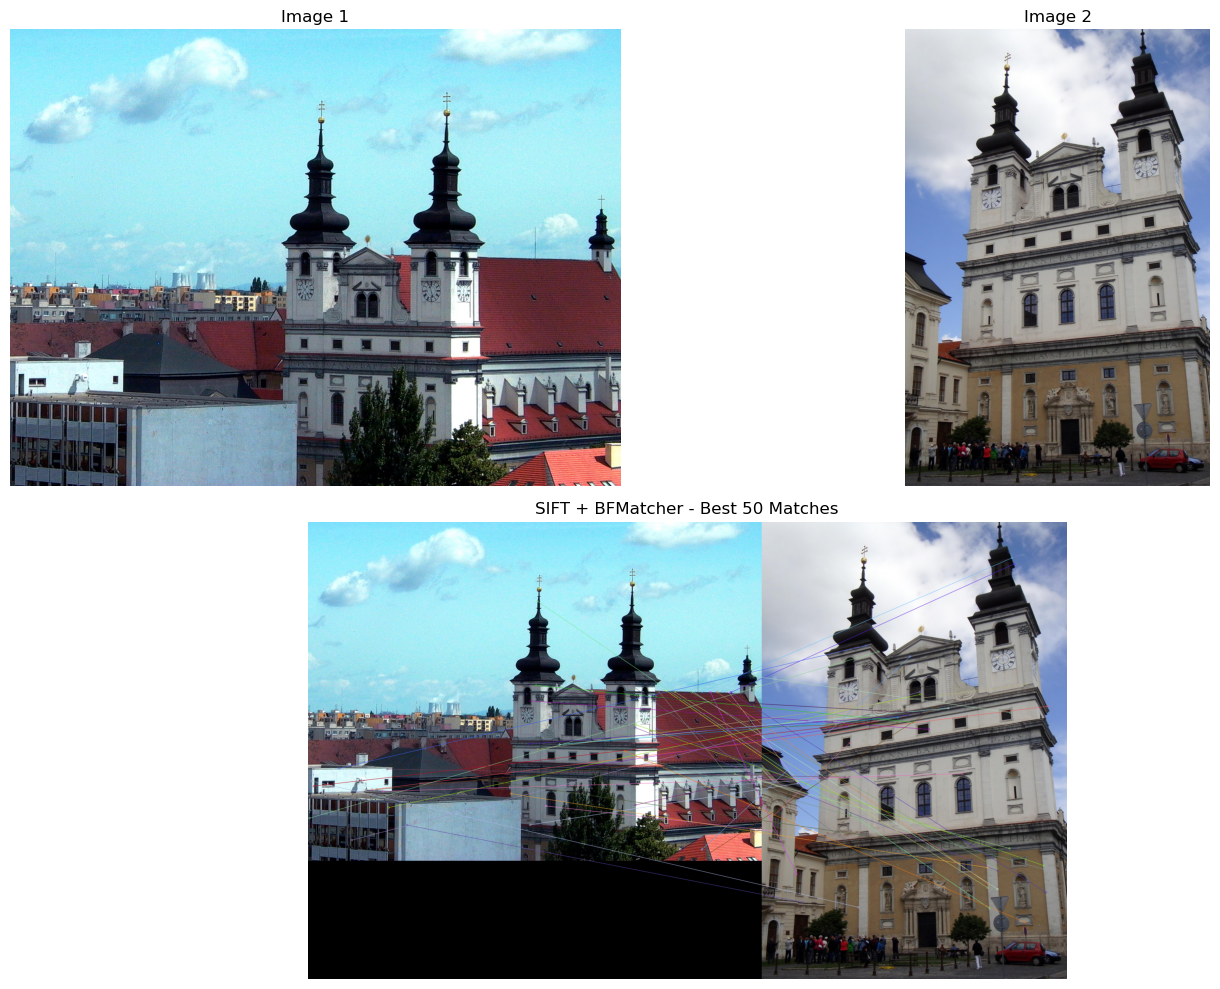

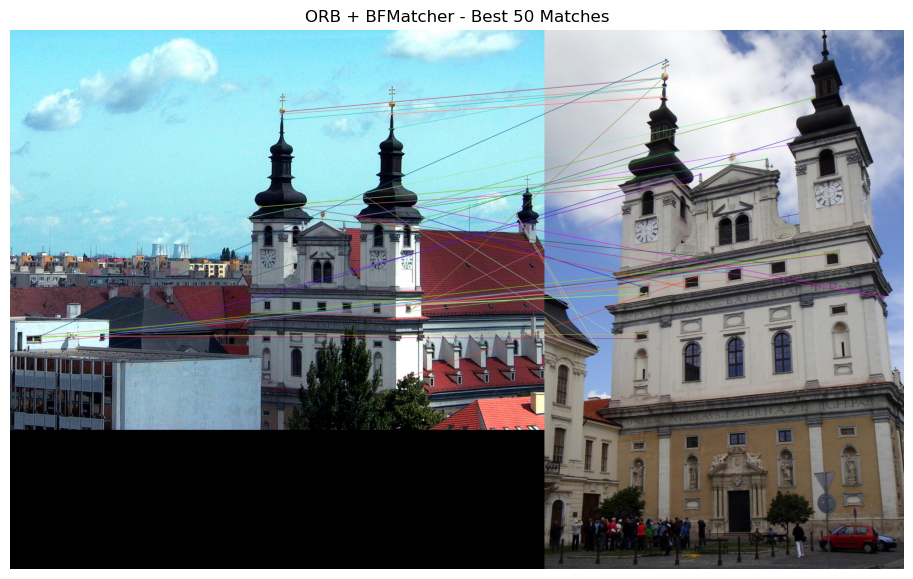

In [41]:
import cv2
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load the two images
# --------------------------------------------------
img1 = cv2.imread("building_1.jpg")
img2 = cv2.imread("building_2.jpg")

if img1 is None or img2 is None:
    print("Error: Could not load images.")
    exit()

# Convert BGR to RGB for displaying with Matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


# ==================================================
# 1. SIFT FEATURE DETECTION
# ==================================================

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
kp1_sift, des1_sift = sift.detectAndCompute(img1, None)
kp2_sift, des2_sift = sift.detectAndCompute(img2, None)

print("SIFT Keypoints in Image 1:", len(kp1_sift))
print("SIFT Keypoints in Image 2:", len(kp2_sift))

# BFMatcher with L2 distance for SIFT
bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match descriptors
sift_matches = bf_sift.match(des1_sift, des2_sift)

# Sort matches according to distance
sift_matches = sorted(sift_matches, key=lambda x: x.distance)

# Draw the best 50 matches
sift_result = cv2.drawMatches(
    img1,
    kp1_sift,
    img2,
    kp2_sift,
    sift_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


# ==================================================
# 2. ORB FEATURE DETECTION
# ==================================================

# Create ORB detector
orb = cv2.ORB_create(nfeatures=1000)

# Detect keypoints and compute descriptors
kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

print("ORB Keypoints in Image 1:", len(kp1_orb))
print("ORB Keypoints in Image 2:", len(kp2_orb))

# BFMatcher with Hamming distance for ORB
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors
orb_matches = bf_orb.match(des1_orb, des2_orb)

# Sort matches according to distance
orb_matches = sorted(orb_matches, key=lambda x: x.distance)

# Draw the best 50 matches
orb_result = cv2.drawMatches(
    img1,
    kp1_orb,
    img2,
    kp2_orb,
    orb_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


# ==================================================
# 3. DISPLAY RESULTS
# ==================================================

plt.figure(figsize=(15, 10))

# Original images
plt.subplot(2, 2, 1)
plt.imshow(img1_rgb)
plt.title("Image 1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img2_rgb)
plt.title("Image 2")
plt.axis("off")

# SIFT matching
plt.subplot(2, 1, 2)
plt.imshow(cv2.cvtColor(sift_result, cv2.COLOR_BGR2RGB))
plt.title("SIFT + BFMatcher - Best 50 Matches")
plt.axis("off")

plt.tight_layout()
plt.show()


# ==================================================
# DISPLAY ORB RESULT SEPARATELY
# ==================================================

plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(orb_result, cv2.COLOR_BGR2RGB))
plt.title("ORB + BFMatcher - Best 50 Matches")
plt.axis("off")
plt.show()